In [20]:
import numpy as np
import matplotlib.pyplot as plt
%run plot_2D.py
# we build time series and we label them, we use a random walk to create data. Our time series is a sequence of random numbers
# where the step at time t depends on the step at time t-1

### Function for the random step
create the random increments of a time series as random walk 

$DX$ is the standard deviation, $bias$ is the constant average of the step

In [21]:
# random seed for reproducibility
np.random.seed(12345)

# function for the random step, using lambda construction
# int() for cleaner look and for mimiking a detector with finite resolution
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

for i in range(10):
    print(jump(5,50))

# we build random increments where random numbers are collect from a gaussian centered on drift

-5
28
-20
-22
103
74
9
19
43
67


### Function for the added pattern
to add to part of a time series, over $z$ bins, with amplitude $a$

In [22]:
#we add a pattern to the random sequence (pattern = sinusoidal function, a = amplitude, z = length on which the pattern 
#is applaied to)
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

[   0.   -5.  -25.   78.   87.  130.  185.  203.  275.  180.  268.  247.
  414.  391.  411.  416.  386.  273.  235.  177.  129.   17.  -55. -115.
  -92.  -71.  -63.  -59.   12.  -60.  -18.   30.   37.   84.   87.   60.
   -1.   40.   95.   69.   38.   45.   90.  145.  101.  100.  114.  114.
  120.  130.  164.   91.   94.   75.  134.  110.   89.  140.   94.  110.] 0
[  0.  28.   6.  80.  99. 166. 107. 123. 172. 159. 143. 171. 125. 136.
 167. 239. 203. 115. 148. 158. 179. 175. 132. 151. 119. 191. 208. 263.
 223. 229. 201. 205. 243. 201.  91.  36.  94. 133. 113.  72.  88.  36.
  62. 158. 205. 255. 368. 473. 517. 485. 497. 474. 433. 436. 490. 574.
 601. 528. 513. 509.] 0
[148.  41.  63.  55.  65.  50.  -6.  80. 107. 177. 167. 131. 161. 175.
 296. 455. 527. 597. 672. 677. 724. 660. 493. 356. 236. 208. 324. 365.
 310. 270. 296. 273. 232. 297. 254. 240. 209. 255. 296. 250. 319. 380.
 400. 347. 220. 188. 265. 246. 245. 208. 276. 259. 216. 252. 312. 300.
 261. 214. 191. 143.] 1
[432. 379. 419. 

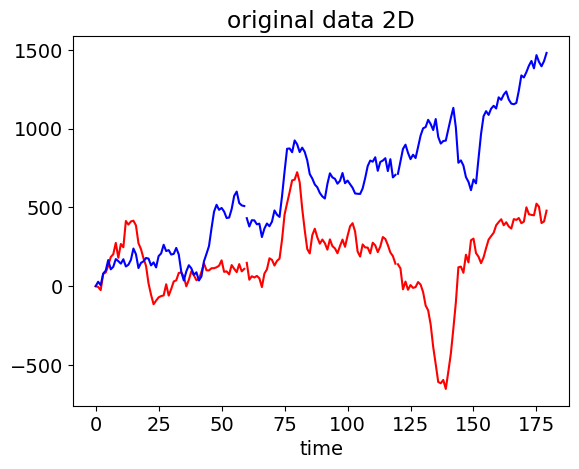

In [37]:

## random seed for reproducibility
np.random.seed(12345)

# pattern parameters: Z=nr of steps, A=amplitude
Z=12
#by decreasing the value of A we hide the pattern under the noise, so it will more difficult for the CNN to find the pattern.
A=500

# number of data samples
N=10000
# size of each sample of the timeseries
L=60
# step parameters: introduce small positive bias (parameters that define the random walk: center of gaussian)
DX = 50 # standard deviation of the random step
bias = 5  # bias to make the random walk drift in the positive direction

y = [0] * N # initialize class labels with zeros
x = np.zeros((N,L,2)) # initialize timeseries with zeros

for i in range(N):
    if i>0:
        # we set the first step of each time series as the last step of the previous one
        x[i,0,0] = x[i-1,-1,0] + jump(bias,DX) # first step of the new sample starts from the last point of the previous one
        x[i,0,1] = x[i-1,-1,1] + jump(bias,DX)
        
    # we populate each sample
    for j in range(1,L):
        x[i,j,0] = x[i,j-1,0] + jump(bias,DX) # random walk with bias
        x[i,j,1] = x[i,j-1,1] + jump(bias,DX)
    # attribute label to each sample
    y[i] = i%3 # assign class labels (0,1,2)
    # if y[i]=0 do nothing
    ##y[i] = random.randint(0,2) # random assingment
    if y[i]>0:
        j0 = np.random.randint(0,L-10-Z) # random starting point for the pattern
        ###print(i,j0,j1)
        sign = 3-2*y[i] # sign of the pattern: + for class 1, - for class 2 (create peak or deep)
        for j in range(Z):
            if y[i]==1:
                x[i,j0+j,0] += sign*pattern(j,Z,A) # add pattern to the timeseries
                x[i,j0+j,1] += sign*pattern(j,Z,A)
            elif y[i]==2:
                x[i,j0+j,0] += sign*pattern(j,Z,A) # add pattern to the timeseries
                x[i,j0+j+10,1] += sign*pattern(j,Z,A)
            
for i in range(min(3,N)):
    print(x[i,:,0],y[i])
    print(x[i,:,1],y[i])
    

Show_data_2D(x,L,"original data 2D")

#in the plot the time flows from 0 to 10000. In the data we have 10000 lines, each with 60 numbers.

### Save data on file

In [38]:
# command in linux
!mkdir DATA_2D
str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.npy'
print(str0)

fname='DATA_2D/x_'+str0
np.save(fname,x)
fname='DATA_2D/y_'+str0
np.save(fname,y)

mkdir: cannot create directory ‘DATA_2D’: File exists
ts_L60_Z12_A500_DX50_bias5_N10000.npy


In [34]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.layers import GlobalMaxPooling1D
%run plot.py

I0000 00:00:1773851466.918740  594395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773851466.918991  594395 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773851466.948829  594395 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773851468.000915  594395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [60]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.npy'
fnamex='DATA_2D/x_'+str0
fnamey='DATA_2D/y_'+str0

x = np.load(fnamex)
categ = np.load(fnamey)

N, L, C = x.shape
print(f"Samples: {N}, Time Steps: {L}, Channels: {C}")

#Show_data_2D(x,L,"original data 2D")

n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

Samples: 10000, Time Steps: 60, Channels: 2
data:  10000


(8000, 60, 2)
N_train= 8000 N_val= 2000   L= 60   n_class= 3
std_train average and mean: 3.1043112140837548 0.21400046128992725 [1. 1.]
std_val average and mean: 3.3263684151442656 0.2607365618858784 [1. 1.]


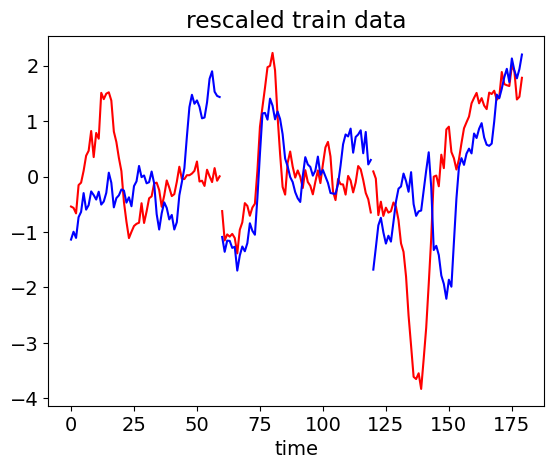

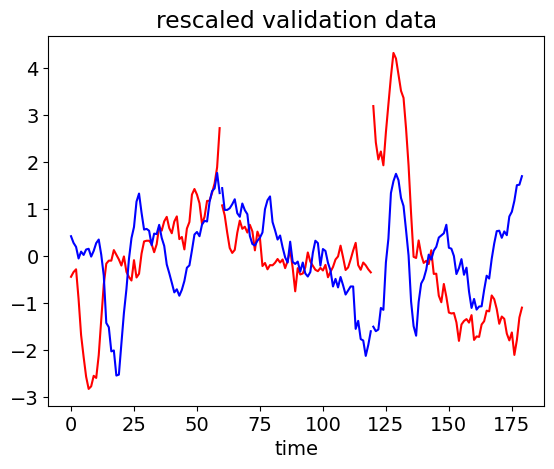

In [48]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train= y[:N_train]
x_val= x[N_train:]
y_val= y[N_train:]

N_val_1 = len(x_val)

print('N_train=',N_train,'N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',np.max(std_train), np.min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',np.max(std_val), np.min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
     
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#
    
Show_data_2D(x_train,L,"rescaled train data")
Show_data_2D(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
#x_train = x_train.reshape(x_train.shape[0], L, 1)
#x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 2) # number of features, number of channels (1 for 1D data)

In [61]:
#np.random.seed(12345)
#import tensorflow.random as tf_r
#tf_r.set_seed(12345)

#reg = tf.keras.regularizers.l2(0.2) 
#ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
 #                                       seed=None)

#NF = 6 
#model = Sequential()

#model.add(Conv1D(filters=NF, kernel_size= 3, 
            #    kernel_initializer=ini, 
             #   kernel_regularizer=reg,
              #  activation='relu', 
               # input_shape=input_shape)) 
    
#model.add(Conv1D(filters=8, kernel_size=9, 
                #activation='relu'))
#model.add(Conv1D(filters=4, kernel_size=3, activation='relu'))
#model.add(GlobalMaxPooling1D())

#model.add(Dense(n_class, activation='softmax')) 
#print(model.summary())

#opt = tf.keras.optimizers.Adam()

#model.compile(loss=keras.losses.categorical_crossentropy,
 #             optimizer=opt,metrics=['accuracy'])


In [62]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

## from keras import regularizers, initializers

reg = tf.keras.regularizers.l2(0.2) ## raised to 0.2 the regularization strenghts
# a high regularization (high penalty) prevents from overfittin in noise scenarios as in this case
# in fact it prevents the model to memorize noise. (Force the model to keep low weights)
#reg = regularizers.l1(0.1)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NCONV = 1 #swtich between 1 and 2 CNNs (there are 2 models: first case 2 conv layers, second we have just 1 conv layer)
NF = 5 #number of filters, will slide across the 60 time step to see
# if there are patterns. The kernel-size is the number od points the filter
# sees each time to decide if a pattern is present.
#each filter search for a different pattern (ie: sharp rise, smooth plateau ecc..)

# challenge: at most 600 tunable parameters
model = Sequential()
# 
if NCONV==1:
    # -----2-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape)) 
    #the output of a convolution layer is a feature map: the filter has its own weights
    # it makes a dot product with each data it sees and sum the products.
    # when the filter recognize the data we have a large value, otherwise we have a 
    # value near zero (for activation = Relu any negative output is turned to zero)
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5)) # takes groups of 5 points and replace them with their average
    # pooling is usefull to smooth the noise.
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
# 
if NCONV==2:
    # -----1-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg, ######## TRY WITHOUT !
                     activation='relu', input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Flatten())
    model.add(Dense(9, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='relu'))
    model.add(Dropout(0.2))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.3))
model.add(Dense(n_class, activation='softmax')) # softmax for both! (to have the final probabilities)
#softmax outputs 3 numbers with sum 1 (probabilities): eg (0.05, 0.9, 0.05)= we are sure that our sample is labeled 1

print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

# 60 parameters after first conv layer because

----- Model 1 -----


/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 50, 5)          │           115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 586 (2.29 KB)

 Trainable params: 586 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [63]:
# plots weights on each layer, regards model 1 with 2 layers
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights, in the plot are the shapes
    # our filters are looking for
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias, decide how strong a pattern 
    # should be before the model recognize it
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
#Show_weights(model,0)
#Show_weights(model, 2)



# we expect that with the training the plot becomes smoother (for weights) and different from zero (for bias)
# In fact, after training each plot of weights will take the shape of the pattern
# it wants to recognize. While for the biases, when a filter learns to recognize a peak,
# its bias will become negative; in this way it will only signal the next layer if the 
# peak i found is strong enough to overcome this negative threshold. This help the model to ignore
# the smaller jumps (DX = 50) and to react only to the big ones (A=500).
# (11 = # weights, 1 = # channel, 5 = # filters)

In [64]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

#print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

Epoch 1/150
40/40 - 1s - 27ms/step - accuracy: 0.3959 - loss: 1.1196 - val_accuracy: 0.5430 - val_loss: 1.0850
Epoch 2/150
40/40 - 0s - 3ms/step - accuracy: 0.5189 - loss: 1.0447 - val_accuracy: 0.5425 - val_loss: 0.9754
Epoch 3/150
40/40 - 0s - 3ms/step - accuracy: 0.5826 - loss: 0.9102 - val_accuracy: 0.6645 - val_loss: 0.7957
Epoch 4/150
40/40 - 0s - 3ms/step - accuracy: 0.6980 - loss: 0.7420 - val_accuracy: 0.7785 - val_loss: 0.6193
Epoch 5/150
40/40 - 0s - 4ms/step - accuracy: 0.7949 - loss: 0.6014 - val_accuracy: 0.8795 - val_loss: 0.4972
Epoch 6/150
40/40 - 0s - 3ms/step - accuracy: 0.8565 - loss: 0.4940 - val_accuracy: 0.9315 - val_loss: 0.3995
Epoch 7/150
40/40 - 0s - 3ms/step - accuracy: 0.9009 - loss: 0.4079 - val_accuracy: 0.9555 - val_loss: 0.3143
Epoch 8/150
40/40 - 0s - 4ms/step - accuracy: 0.9221 - loss: 0.3353 - val_accuracy: 0.9695 - val_loss: 0.2446
Epoch 9/150
40/40 - 0s - 4ms/step - accuracy: 0.9408 - loss: 0.2738 - val_accuracy: 0.9805 - val_loss: 0.1913
Epoch 10/

Validation accuracy =  0.9965000152587891


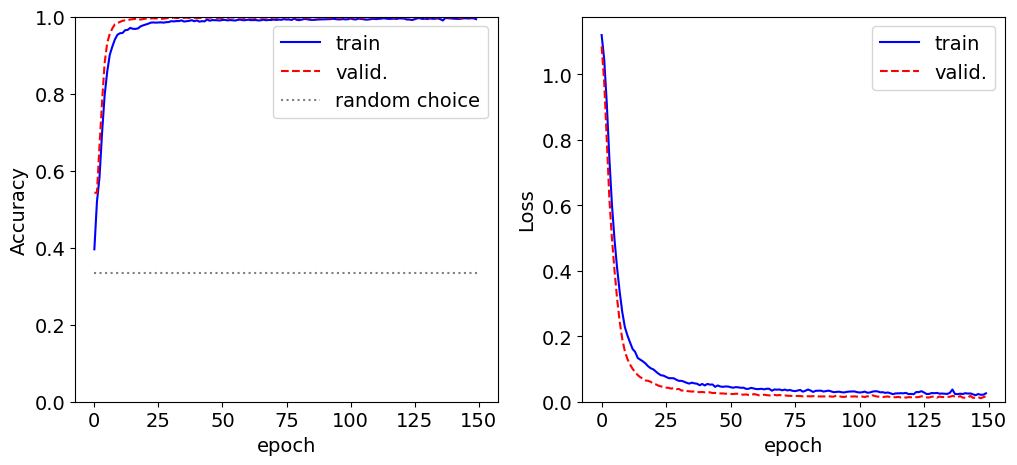

(11, 2, 5)
(5, 2, 11)


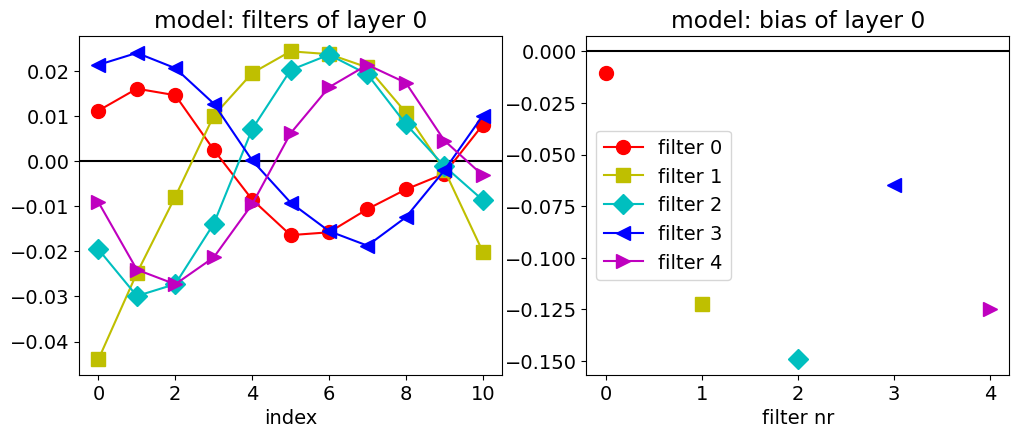

(7, 5, 5)
(5, 5, 7)


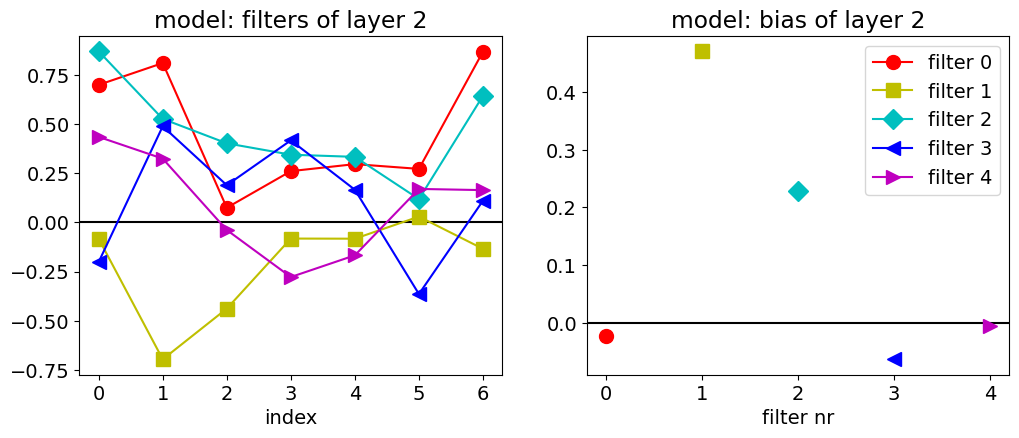

In [65]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
print("Validation accuracy = ", fit.history['val_accuracy'][-1])
Show_history(fit)
Show_weights(model,0)
Show_weights(model,2)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


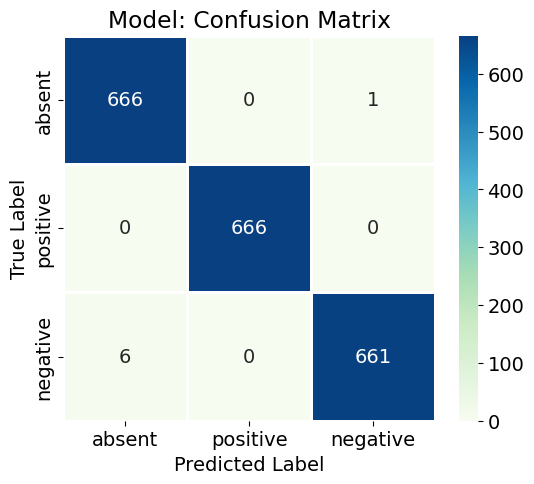

In [66]:
# confusion table: compare true labels with predicted ones
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

y_pred_val = model.predict(x_val)
#y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)
#max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
#show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")

#print(classification_report(max_y_val, max_y_pred_val))